# Homework 3 Part 1 - Solutions

This is an individual assignment.

---

Solve all problems by hand. You may type your answers in markdown cells or ```push``` a PDF file with your handwritten answers.

---

# Problem 1 (10 points)

**Consider a binary classification task where each sample $\mathbf{x}_i$ is $d$-dimensional with its corresponding label $t_i\in\{0,1\}$. Suppose you have a dataset of $N$ i.i.d. samples, $\{(x_i,t_i)\}_{i=1}^N$. Let $\mathbf{m}_i$ be the sample average for class $C_i$, $\mathbf{m}_i\in\mathbb{R}^d$.**

**The goal is to train a discriminant function of the form**

$$y(\mathbf{x})=\mathbf{w}^T\mathbf{x}+w_0$$ 

**to separate the two classes. Recall that the vector $\mathbf{w}$ is orthogonal to the discriminant function $y(\mathbf{x}$ and that we are only interested in its direction not magnitude, thus the solution for $\mathbf{w}$ must satisfy the (equality) constraint $\mathbf{w}^T\mathbf{w}=1$. Answer the following questions:**

1. (8 points) **Suppose that you are interested in finding $\mathbf{w}$ and $w_0$ such that the projected class means are the most separable. Write down the objective function, the Lagrangian function, and derive for the analytical solutions for $\mathbf{w}$ and $w_0$.**

The objective function can be written as:

\begin{align*}
J(\mathbf{w}) &= \mathbf{w}^T(\mathbf{m}_1-\mathbf{m}_2)^T(\mathbf{m}_1-\mathbf{m}_2)\mathbf{w} = \mathbf{w}^T S_B \mathbf{w}
\end{align*}

where $S_B = (\mathbf{m}_1-\mathbf{m}_2)^T(\mathbf{m}_1-\mathbf{m}_2)$. The optimization problem is posed as,

\begin{align*}
\arg_{\mathbf{w}} \max \;\; & \mathbf{w}^TS_B\mathbf{w} \\
\text{subject to} & \;\; \mathbf{w}^T\mathbf{w}=1
\end{align*}

The Lagrangian function is:

\begin{align*}
\mathcal{L} = \mathbf{w}^TS_B\mathbf{w} + \lambda (1 - \mathbf{w}^T\mathbf{w})
\end{align*}

Deriving for $\mathbf{w}$:

\begin{align*}
\frac{\partial\mathcal{L}}{\partial\mathbf{w}} = 0 \iff S_B\mathbf{w} = \lambda\mathbf{w}
\end{align*}

Thus the solution for $\mathbf{w}$ is the eigenvector of $S_B$ with the **largest** eigenvalue. Lastly, the solution for $w_0$ is $-\frac{(\mathbf{m}_1+\mathbf{m}_2)^T\mathbf{w}}{2}$.

2. (2 points) **How would you change your approach if it is known that the dataset contains outliers?**

Instead of the mean, one can use a different statistic that is more robust to outliers, such as the median or inter-quantile range (IQR).

---

# Problem 2 (7 points)

**Recall that the soft-margin Support Vector Machine objective function is**

$$C\sum_{n=1}^N \xi_n + \frac{1}{2} \Vert w\Vert^2$$

**subject to the constraints**

\begin{align*}
t_n y(x_n) &\geq 1 - \xi_n, n = 1, \dots, N \\
\xi_n &\geq 0, n = 1, \dots, N
\end{align*}

**Answer the following questions:**

1. (2 points) **From the training set, which points are used to make predictions during the test stage? Explain your reasoning.**

2. (5 points) **$C$ is a parameter that is set by the user. Describe the relationship between values of $C$ and (1) the resulting SVM decision surface, (2) performance and (3) number of support vectors.**

1. During training, each sample $x_n$ will have an associated Lagrange multiplier $a_n\geq 0$. Sample points that are correctly classified (away from the margin) will have an associated slack variable $\xi_n=0$ and the Lagrange multiplier $a_n=0$.

All other points will have $a_n>0$:

* If $0<a_n<C$, then $\mu_n>0$ (because $a_n = C-\mu_n$) thus $\xi_n=0$. So $x_n$ is a support vector (exactly on the margin).

* If $a_n = C$, then all corresponding samples $x_n$ will have $\mu_n=0$ and $\xi_n>0$. So $x_n$ is either correctly classified but inside the margin ($0<\xi_n<1$) or misclassified ($\xi_\geq 1$).

In summary, samples $x_n$ that are support vectors, inside the margin or misclassified are used to make inferences during the test stage.

2. The parameter $C$ controls the trade-off between slack variable and the margin. Decreasing $C$ will soften the margin and increase the number of support vectors.

---

# Problem 3 (18 points)

**Complete the following table for the classifiers listed below (3 points/classifier). Under "Type" list: generative, discriminative or probabilistic discriminative. Under "Convergence" list whether the convergence is guaranteed or any other conditions for the converged solution.**

| Classifier | Type | Mapper function | Objective Function | Learning Algorithm | Assumptions | Computational Complexity | Sensitive to outliers? | Convergence |
| -- | -- | -- | -- | -- | -- |  -- | -- | -- |
| Naïve Bayes Classifier |    |    |    |    |    |    |    |    |
| Fisher's LDA |    |    |    |    |    |    |    |    |
| Perceptron |    |    |    |    |    |    |    |    |
| Logistic Regression |    |    |    |    |    |    |    |    |
| Hard-margin SVM |    |    |    |    |    |    |    |    |
| Soft-margin SVM |    |    |    |    |    |    |    |    |

**Naïve Bayes Classifier**
1. **Type:** generative
2. **Mapper function:**
$$i = \arg_k\max P(C_k|\mathbf{x}) = arg_k\max \frac{P(\mathbf{x}|C_k)P(C_k)}{P(\mathbf{x})}$$
3. **Objective function:** find label that maximizes posterior probability $P(C_k|\mathbf{x})$. This requires learning the data likelihood $P(\mathbf{x}|C_k)$ based on training dataset. In class, we assume a parametric form of $P(\mathbf{x}|C_k) \forall k$ and used MLE or MAP to find its parameters. But there are other approaches to estimate density functions namely with non-parametric approaches.
4. **Learning algorithm:** Bayes theorem
5. **Assumptions:** assumes that features are conditionally independent if $P(\mathbf{x}|C_k)$ are Gaussian-distributed (thus being "naïve")
6. **Computational Complexity:** $O(dK)$, where $d$ is the dimensionality and $K$ the number of classes
7. **Sensitive to Outliers?:** yes, it will affect the parameter estimation of $P(\mathbf{x}|C_k)$
8. **Convergence:** unique guaranteed solution

**Fisher's LDA**
1. **Type:** discriminative
2. **Mapper function:**
$$y(\mathbf{x}) =\begin{cases} 1 & \text{if}\; \mathbf{w}^T\mathbf{x} + w_0>0\\ 0 & \text{otherwise}\end{cases}$$

3. **Objective function:**
$$J(\mathbf{w},w_0) = \frac{ \mathbf{\overrightarrow{w}}^T \mathbf{S}_B \mathbf{\overrightarrow{w}}}{\mathbf{\overrightarrow{w}}^T\mathbf{S}_W\mathbf{\overrightarrow{w}}}$$

4. **Learning algorithm:** eigendecomposition of $\mathbf{S}_W^{-1}\mathbf{S}_B$
5. **Assumptions:** classes are Gaussian
6. **Computational Complexity:** if sample size ($N$) is larger than dimensionality ($d$), then $O(Nd^2)$, otherwise $O(d^3)$
7. **Sensitive to Outliers?:** yes, hyperplane will be affected by 
8. **Convergence:** unique guaranteed solution

**Perceptron**
1. **Type:** discriminative
2. **Mapper function:** 
$$y(\mathbf{x}) =\phi(\mathbf{w}^T\mathbf{x} + w_0)$$

where $\phi(x) = \begin{cases}1 & x>0 \\ -1 & x\leq 0\end{cases}$

3. **Objective function:**
$$E_p(\mathbf{w},w_0) = - \sum_{n\in\mathcal{M}} (\mathbf{w}^T \mathbf{x}_n + w_0) t_n$$

4. **Learning algorithm:** stochastic gradient descent
5. **Assumptions:** classes are linearly separable
6. **Computational Complexity:** $O\left(\frac{1}{\epsilon}\right)$, where $\epsilon$ is the generalization error
7. **Sensitive to Outliers?:** yes
8. **Convergence:** only guaranteed in a finite set of steps if classes are linearly separable

**Logistic Regression**
1. **Type:** probabilistic discriminative
2. **Mapper function:** 
$$y(\mathbf{x}) = \begin{cases} 1 & \phi(\mathbf{w}^T\mathbf{x} + w_0)\geq 0.5 \\ 0 & \text{otherwise} \end{cases}$$

where $\phi(x) = \frac{1}{1+e^{-x}}$

3. **Objective function:**

$$J(\mathbf{w},w_0) = \sum_{i=1}^N - t_i\log\phi(\mathbf{w}^T\mathbf{x}_i + w_0) - (1-t_i)\log(1-\phi(\mathbf{w}^T\mathbf{x}_i + w_0))$$

4. **Learning algorithm:** gradient descent
5. **Assumptions:** samples and features are independent
6. **Computational Complexity:** $O(d)$
7. **Sensitive to Outliers?:** yes
8. **Convergence:** cross-entropy is a convex function. It guarantees solution to global minima. Quality of solution will depend on the number of epochs used.

**Hard-margin SVM**
1. **Type:** discriminative
2. **Mapper function:** 
$$y(\mathbf{x}) = \mathbf{w}^T\phi(\mathbf{x}) + w_0$$

3. **Objective function:**

$$L(\mathbf{w},w_0,\mathbf{a}) = \frac{1}{2}\Vert \mathbf{w}\Vert^2 - \sum_{n=1}^N a_n \left(t_n(\mathbf{w}^T\phi(\mathbf{x}_n) + w_0) - 1\right), \;\; a_n\geq 0\; \forall n$$

4. **Learning algorithm:** quadratic programming
5. **Assumptions:** classes are linearly separable in feature mapping $\phi(\cdot)$
6. **Computational Complexity:** $O(N^3)$
7. **Sensitive to Outliers?:** only for outliers near the margin
8. **Convergence:** guaranteed to unique solution

**Soft-margin SVM**
1. **Type:** discriminative
2. **Mapper function:** 
$$y(\mathbf{x}) = \mathbf{w}^T\phi(\mathbf{x}) + w_0$$

3. **Objective function:** 

$$L(\mathbf{w}, w_0, \mathbf{a}, \mathbf{\mu}) = \frac{1}{2} \Vert \mathbf{w}\Vert^2 + C\sum_{n=1}^N \xi_n - \sum_{n=1}^N a_n \left(t_n y(\mathbf{x}_n) - 1 + \xi_n\right) - \sum_{n=1}^N \mu_n\xi_n$$

4. **Learning algorithm:** quadratic programming
5. **Assumptions:** classes are linearly separable in feature mapping $\phi(\cdot)$
6. **Computational Complexity:** $O(N^3)$
7. **Sensitive to Outliers?:** only for outliers near the margin
8. **Convergence:** guaranteed to unique solution

---

# Problem 4 (5 points)

**Draw a Perceptron to implement the NAND gate $\overline{A \cap B} = \overline{A} \cup \overline{B}$ using the threshold activation function $\phi(x) = \begin{cases}1, & x>0 \\ 0, & x\leq 0\end{cases}$. Specify the numerical values for the weights and bias.**

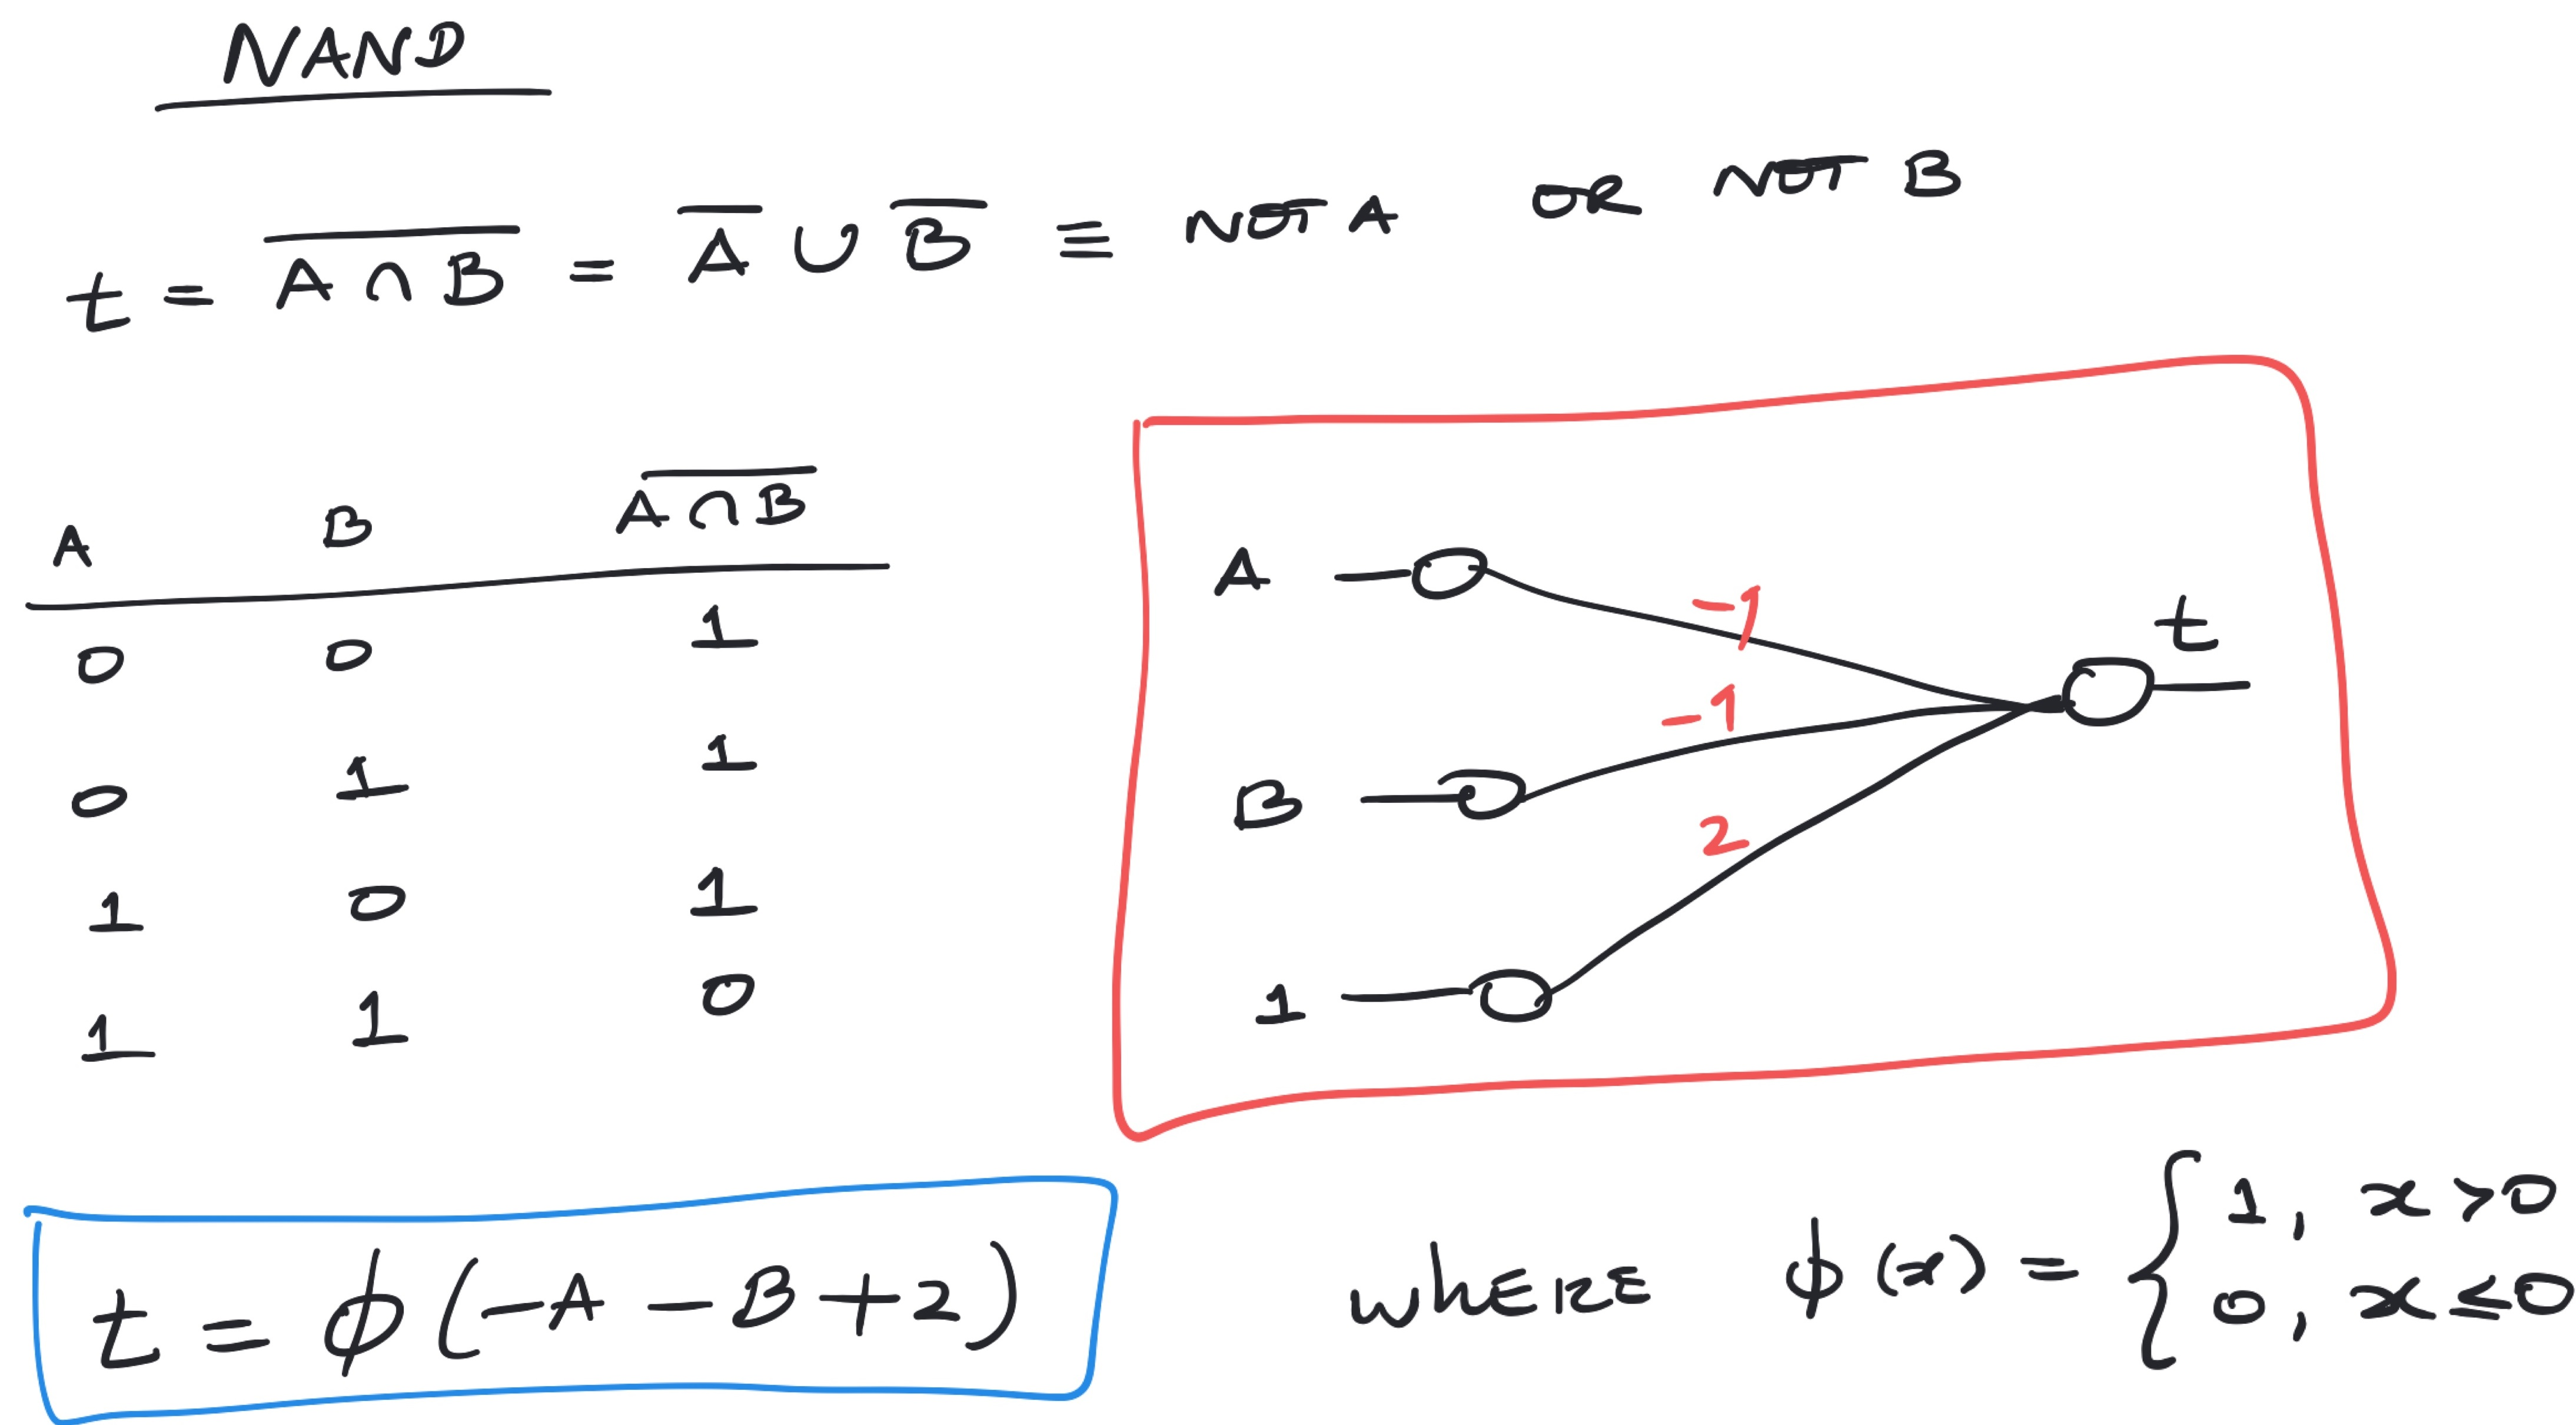

In [3]:
Image('figures/nand_gate.jpg', width=800)

---

# Problem 5 (5 points)

**Consider the following performance from five different classifiers, A, B, C and D on three data sets. The classifiers used to produce these results are: Fisher's Linear Discriminant, k-NN with k=3, Naïve Bayes classifier, and SVM with RBF kernel.**

**Which classifier corresponds to which performance? Clearly justify your reasoning.**

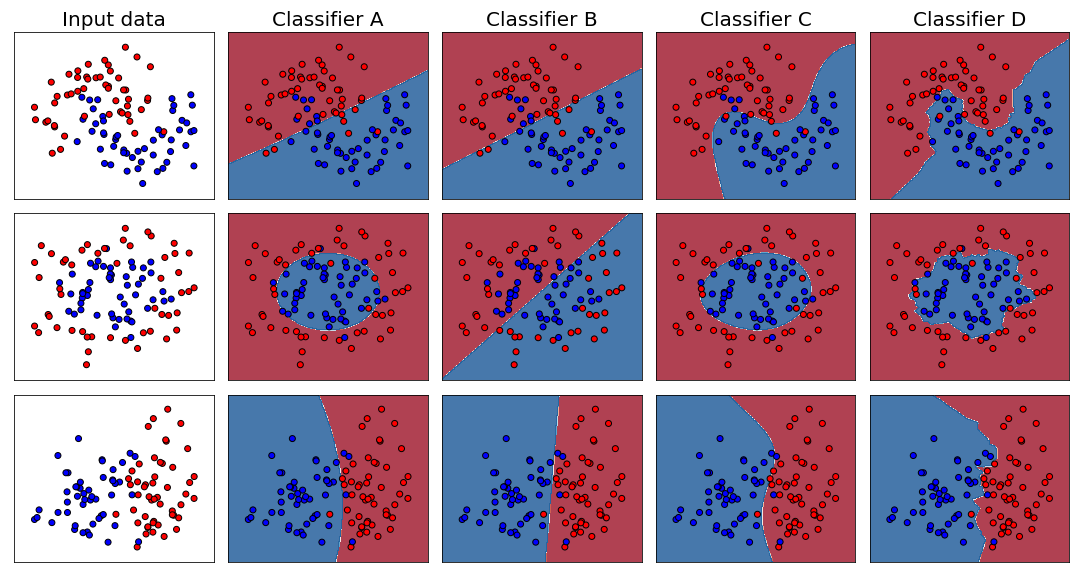

In [5]:
Image('figures/Classifiers.png', width=900)

Classifier A is the Naive Bayes Classifier. As the decision surface best represents the Gaussianity assumption for each class.

Classifier B is the LDA classifier. The decision surface corresponds to a linear discriminant function.

Classifier C is the SVM classifier. As it creates non-linear boundaries that are smoother than the MLP classifier due to the RBF kernel.

Classifier D is the kNN classifier. The kNN decision surface is non-smooth for regions of overlapping classes.

---

# On-Time (5 points)

Submit your assignment before the deadline.

___

# Submit Your Solution

Confirm that you've successfully completed the assignment.

Along with the Notebook, include a PDF of the notebook with your solutions.

```add``` and ```commit``` the final version of your work, and ```push``` your code to your GitHub repository.

Submit the URL of your GitHub Repository as your assignment submission on Canvas.

___